In [41]:
from time import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [42]:
iris_df = pd.read_csv("/home/vhvhs/ML/Datasets/Iris.csv").drop(columns='Id', axis=0)
iris_df.sample(n=5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
95,5.7,3.0,4.2,1.2,Iris-versicolor
79,5.7,2.6,3.5,1.0,Iris-versicolor
23,5.1,3.3,1.7,0.5,Iris-setosa
22,4.6,3.6,1.0,0.2,Iris-setosa
96,5.7,2.9,4.2,1.3,Iris-versicolor


In [43]:
iris_df['Species'].value_counts(sort=False)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [44]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


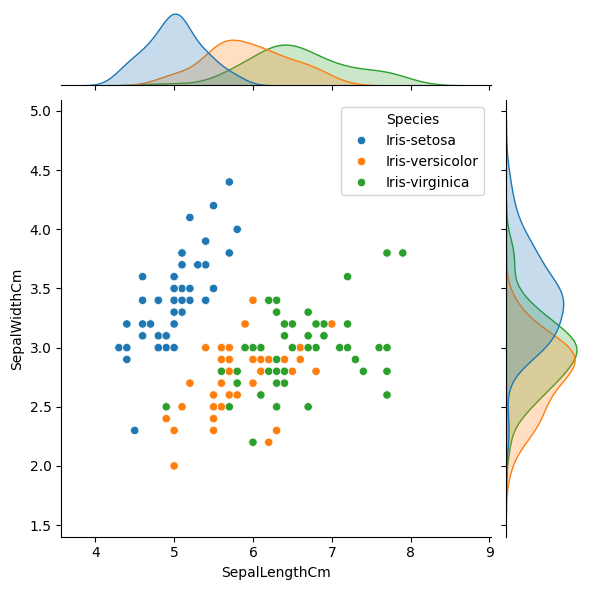

In [45]:
sns.jointplot(data=iris_df, x="SepalLengthCm", y="SepalWidthCm", hue="Species")

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

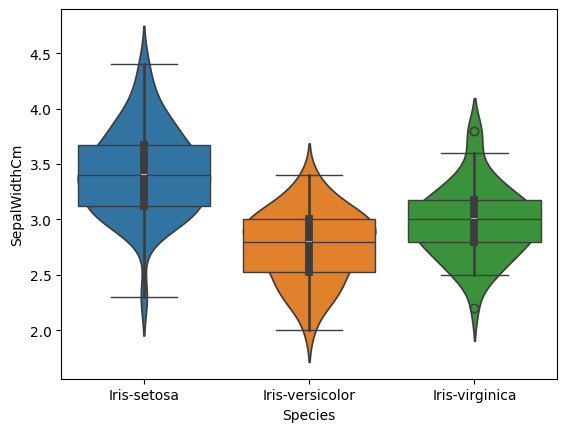

In [46]:
sns.boxplot(data=iris_df, y="SepalWidthCm", x="Species", hue="Species")
sns.violinplot(data=iris_df, y="SepalWidthCm", x="Species", hue="Species")

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

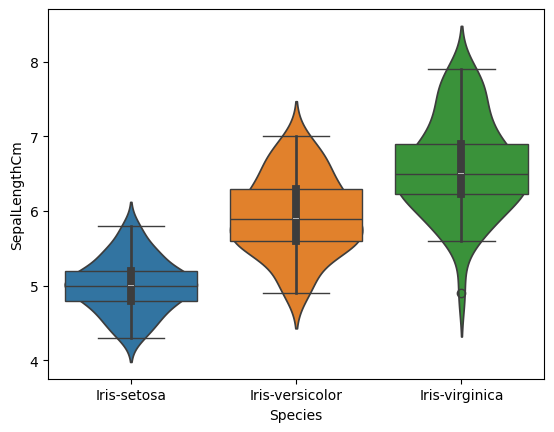

In [47]:
sns.boxplot(data=iris_df, y="SepalLengthCm", x="Species", hue="Species")
sns.violinplot(data=iris_df, y="SepalLengthCm", x="Species", hue="Species")

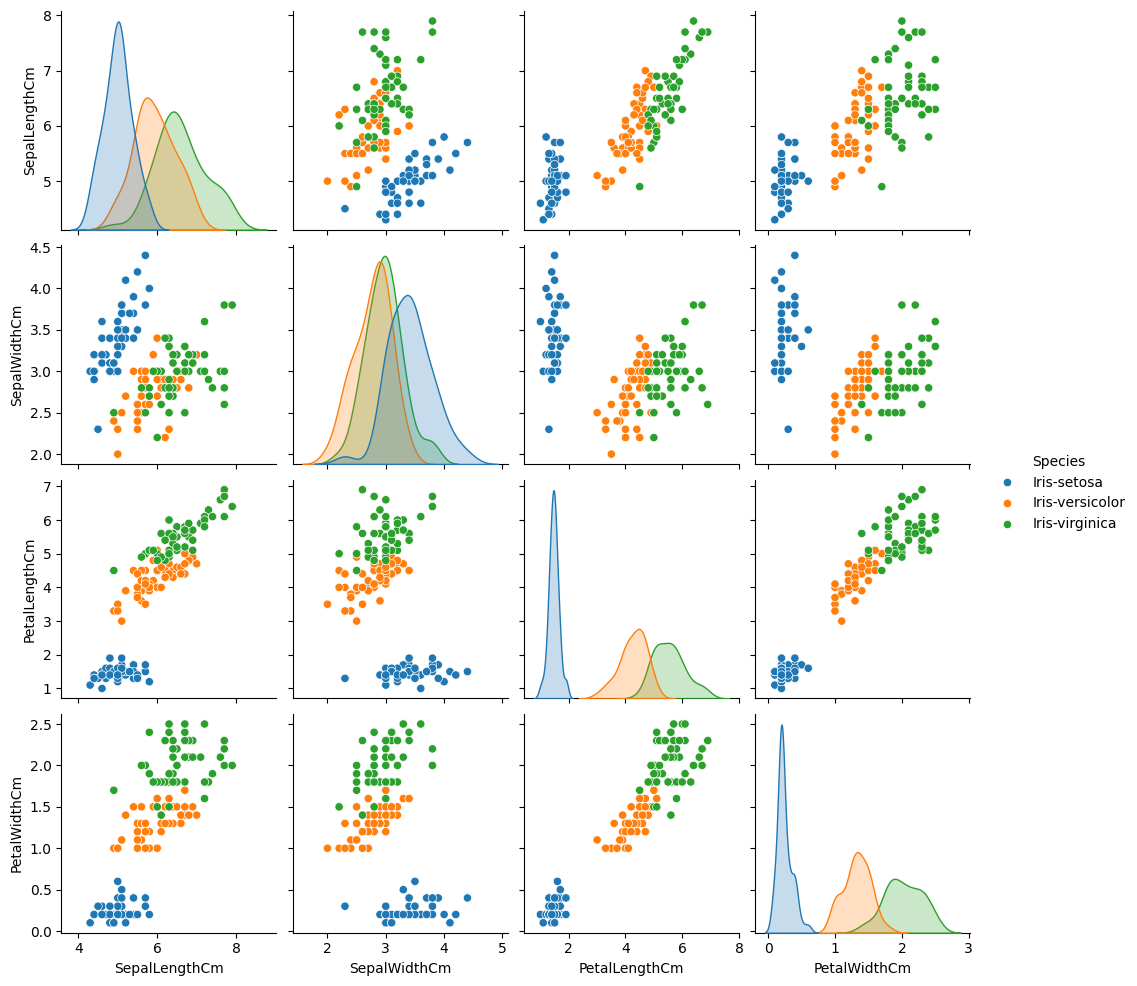

In [48]:
sns.pairplot(data=iris_df, hue="Species")

<Axes: >

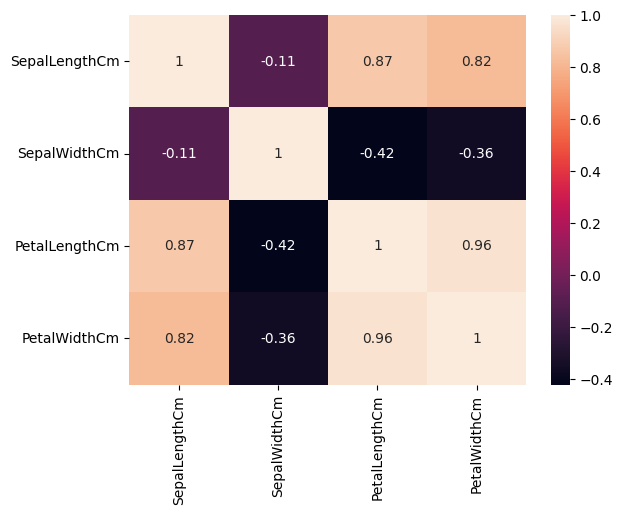

In [49]:
sns.heatmap(iris_df.drop(columns="Species").corr(), annot=True)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(iris_df.iloc[:, :-1], iris_df.iloc[:, -1], random_state=41, test_size=0.2)

In [ ]:
std_features = X_train.columns

pipe = Pipeline(
    [
        ('std', StandardScaler()),
        ('model', LogisticRegression(solver='sag'))
    ]
)

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('std', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work 

In [55]:
model_accuracy_score = accuracy_score(y_test, pipe.predict(X_test))
model_confusion_matrix = confusion_matrix(y_test, pipe.predict(X_test))
model_classification_report = classification_report(y_test, pipe.predict(X_test))

print("Model accuracy:\n", model_accuracy_score)
print("Model Confusion Matrix:\n", model_confusion_matrix)
print("Model Classification Matrix:\n", model_classification_report)

Model accuracy:
 0.9
Model Confusion Matrix:
 [[ 9  0  0]
 [ 0 10  1]
 [ 0  2  8]]
Model Classification Matrix:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.83      0.91      0.87        11
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.91      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



In [ ]:
print("Cross val accuracy score: ", np.mean(cross_val_score(pipe, X, y.to_numpy(), cv = 5, scoring='accuracy')))
print("Cross val score std deviation: ", cross_val_score(pipe, X_std, y, cv = 5).std())
print("Cross val score: ", np.mean(cross_val_score(pipe, X=X, y=y, cv = 5, scoring='f1_weighted')))